In [1]:
using Distributions
using MLUtils: DataLoader
using LinearAlgebra

using KernelFunctions

using CairoMakie
using ColorSchemes
import Polynomials
using DataFrames
using CSV 

include("src/rgp.jl")
include("src/battModel.jl")
using .RecursiveGPs
using .battModel


In [2]:
df_profile = CSV.read("data/profile.csv", DataFrame);
df_ocv = CSV.read("data/ocv.csv", DataFrame);

In [14]:
## Battery model

R1 = 15e-3
τ1 = 60.0
R2 = 15e-3
τ2 = 600.0

Q_batt = I(3) * 10e-6
R_batt = 1e-6

μ = [0.0; 0.0; 0.0];

batt = battModel.BATTModel(μ, Q_batt, R_batt, R1, τ1, R2, τ2);

In [15]:
## Ocv model
ocv = Polynomials.fit(df_ocv.soc, df_ocv.ocv, 3);

In [16]:
## RGP for R0
n_basis = 9
X_basis = collect(range(0, stop=1, length=n_basis))

kernel = 1 * with_lengthscale(SEKernel(), 1)
σ = 0.001

gp_r0 = RecursiveGPs.RGPModel(kernel, σ, X_basis);

In [17]:
N_points = 5000
data_profile = DataLoader((x=df_profile[1:N_points, Not(:v)], y=df_profile[1:N_points, :v]), batchsize=1, shuffle=false);

In [18]:
first_kl = true


## First Apply Kalman filter then RGP learn
## batch size = 1, higer batch size lead to divergence
if first_kl == true
    for (n, d) in enumerate(data_profile)
        x = d.x
        y = d.y
        
        battModel.learn_batt!(batt, ocv, gp_r0, x, y)

        x_rgp = [batt.μ[1]]
        y_rgp = [max(0,(y[1] - ocv(batt.μ[1]) - batt.μ[2] - batt.μ[3])/x.i[1])]
        RecursiveGPs.learn!(gp_r0, x_rgp, y_rgp)
    end


## First RGP then Kalman filter
else
    for (n, d) in enumerate(data_profile)
        x = d.x
        y = d.y
        x_rgp = [batt.μ[1]]
        y_rgp = [max(0,(y[1] - ocv(batt.μ[1]) - batt.μ[2] - batt.μ[3])/x.i[1])]
        RecursiveGPs.learn!(gp_r0, x_rgp, y_rgp)
        battModel.learn_batt!(batt, ocv, gp_r0, x, y)
    end
end

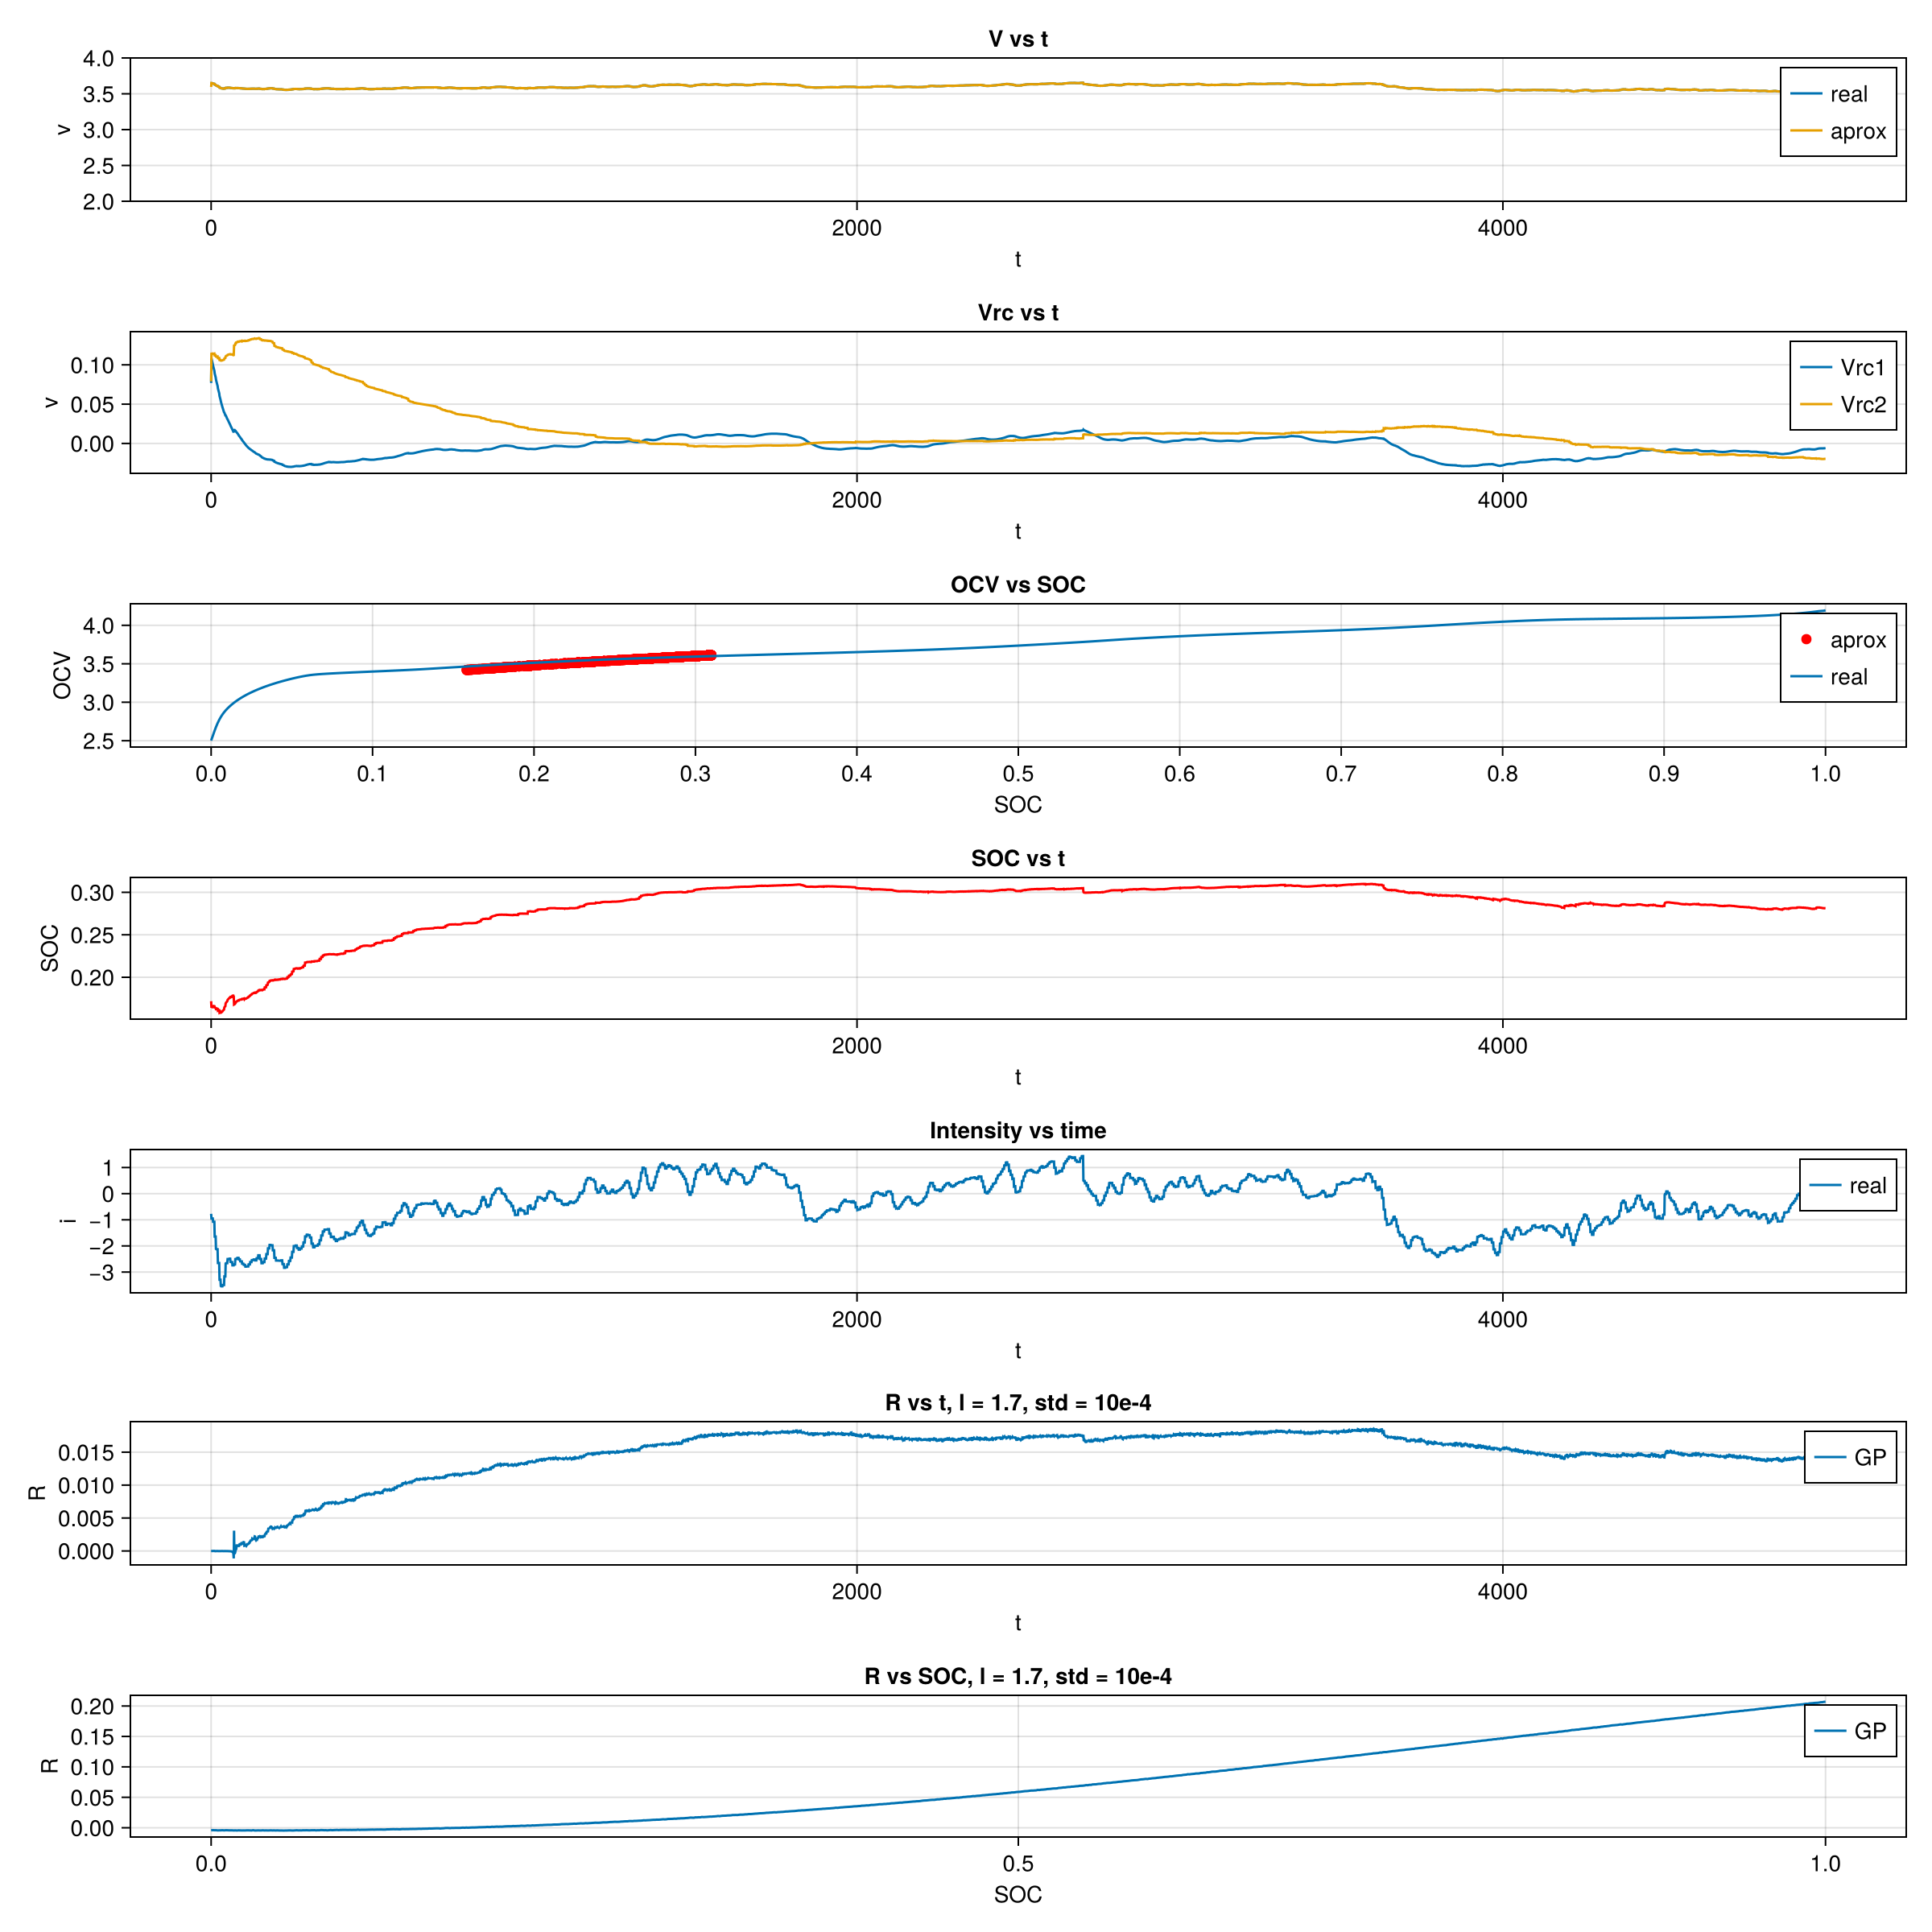

CairoMakie.Screen{IMAGE}


In [19]:
R0_profile = RecursiveGPs.predict(gp_r0, df_ocv.soc).μ


fig = Figure(size=(1200, 1200))
#Label(fig[0, :], "R0 as rgp with transformed SOC", fontsize=20, halign=:center)
## Voltage
ax = Axis(fig[1, 1], title="V vs t", xlabel="t", ylabel="v")
lines!(ax, batt.data.t, df_profile[1:N_points, :v], label="real")
lines!(ax, batt.data.t, batt.data.V̂, label="aprox")
ax.limits = (nothing, (2, 4))

## Voltage RC over time
ax2 = Axis(fig[2, 1], title="Vrc vs t", xlabel="t", ylabel="v")
lines!(ax2, batt.data.t, batt.data.Vrc1, label="Vrc1")
lines!(ax2, batt.data.t, batt.data.Vrc2, label="Vrc2")

## OCV
ax3 = Axis(fig[3, 1], title="OCV vs SOC", xlabel="SOC", ylabel="OCV")
ax3.xticks = 0:0.1:1  
scatter!(ax3, batt.data.soc, ocv.(batt.data.soc), label="aprox", color = :red)
lines!(ax3, df_ocv.soc , df_ocv.ocv, label="real")

#SOC 
ax7 = Axis(fig[4, 1], title="SOC vs t", xlabel="t", ylabel="SOC")
lines!(ax7, batt.data.t, batt.data.soc, label="aprox", color = :red)

## i
ax4 = Axis(fig[5, 1], title="Intensity vs time", xlabel="t", ylabel="i")
lines!(ax4, batt.data.t, batt.data.i , label="real")

## R
ax5 = Axis(fig[6, 1], title="R vs t, l = 1.7, std = 10e-4", xlabel="t", ylabel="R")
lines!(ax5, batt.data.t, batt.data.R0 , label="GP")

## R
ax6 = Axis(fig[7, 1], title="R vs SOC, l = 1.7, std = 10e-4", xlabel="SOC", ylabel="R")
lines!(ax6, df_ocv.soc, R0_profile , label="GP")


axislegend(ax)
axislegend(ax2)
axislegend(ax3)
axislegend(ax4)
axislegend(ax5)
axislegend(ax6)

save("pictures/5000_first_gp.png", fig)
display(fig)